# Autonomous Floor Plan Analysis using Deep Learning on RPlan Dataset
**Researcher:** Seyed Mehdi Safari  
**Hardware:** MacBook M3 Pro (Apple Silicon MPS Acceleration)  

## 1. Introduction
This research notebook focuses on the task of **Semantic Image Segmentation** applied to architectural floor plans. Using the RPlan dataset, we train a custom **U-Net** architecture to take grayscale wall structures as input and predict the full, color-coded functional rooms (Living room, bedroom, kitchen, etc.).

In [6]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Device configuration for MacBook M3 Pro
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Research environment initialized on: {device} 🚀")

Research environment initialized on: mps 🚀


# Exploratory Data Analysis - EDA

In [7]:
class RPlanResearchDataset(Dataset):
    def __init__(self, data_dir, img_size=(256, 256)):
        self.data_dir = data_dir
        self.img_size = img_size
        self.image_filenames = [f for f in os.listdir(data_dir) if f.endswith('.png')]
        self.transform = transforms.Compose([
            transforms.Resize(self.img_size),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.data_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        img_np = np.array(image)
        walls_mask = np.all(img_np < 50, axis=-1).astype(np.float32)
        walls_img = Image.fromarray((walls_mask * 255).astype(np.uint8))
        
        x_input = self.transform(walls_img)
        y_target = self.transform(image)
        return x_input, y_target

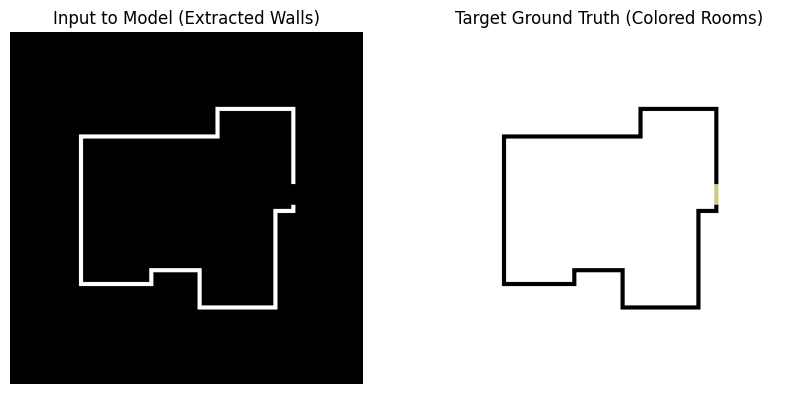

In [ ]:
DATA_DIR = "./data/Img"
dataset = RPlanResearchDataset(DATA_DIR)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

# Get one sample to visualize
inputs, targets = next(iter(dataloader))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Input to Model (Extracted Walls)")
plt.imshow(inputs[0].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Target Ground Truth (Colored Rooms)")
plt.imshow(targets[0].permute(1, 2, 0))
plt.axis('off')

plt.show()

# Model Architecture (U-Net)

In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=3):
        super().__init__()
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(128, 64)
        self.outc = nn.Sequential(nn.Conv2d(64, out_channels, kernel_size=1), nn.Sigmoid())

    def forward(self, x):
        x1 = self.inc(x); x2 = self.down1(x1); x3 = self.down2(x2); x4 = self.down3(x3)
        x = self.up1(x4); x = torch.cat([x, x3], dim=1); x = self.conv1(x)
        x = self.up2(x); x = torch.cat([x, x2], dim=1); x = self.conv2(x)
        x = self.up3(x); x = torch.cat([x, x1], dim=1); x = self.conv3(x)
        return self.outc(x)

# Training & Loss Optimization

In [10]:
# Hyperparameters
EPOCHS = 5
BATCH_SIZE = 16
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

model = UNet().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_history = []

print("Starting Training Loop...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs_b, targets_b in train_loader:
        inputs_b, targets_b = inputs_b.to(device), targets_b.to(device)
        
        optimizer.zero_grad()
        outputs_b = model(inputs_b)
        loss = criterion(outputs_b, targets_b)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss: {epoch_loss:.5f}")

torch.save(model.state_dict(), "unet_rplan_latest.pth")

Starting Training Loop...
Epoch [1/5] -> Loss: 0.02429
Epoch [2/5] -> Loss: 0.00123
Epoch [3/5] -> Loss: 0.00049
Epoch [4/5] -> Loss: 0.00026
Epoch [5/5] -> Loss: 0.00016


# Results & Visual Evaluation

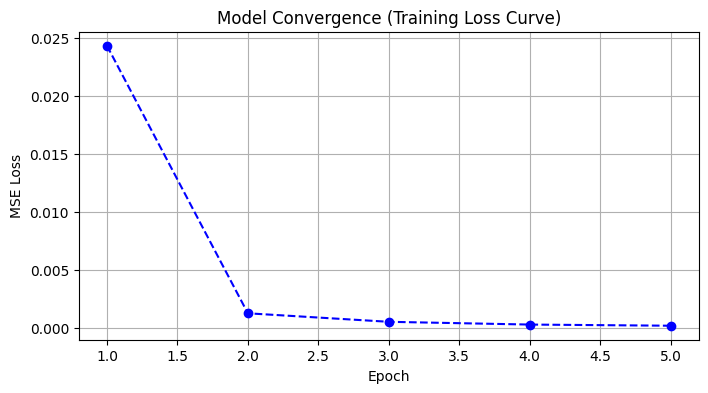

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), loss_history, marker='o', color='b', linestyle='dashed')
plt.title("Model Convergence (Training Loss Curve)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

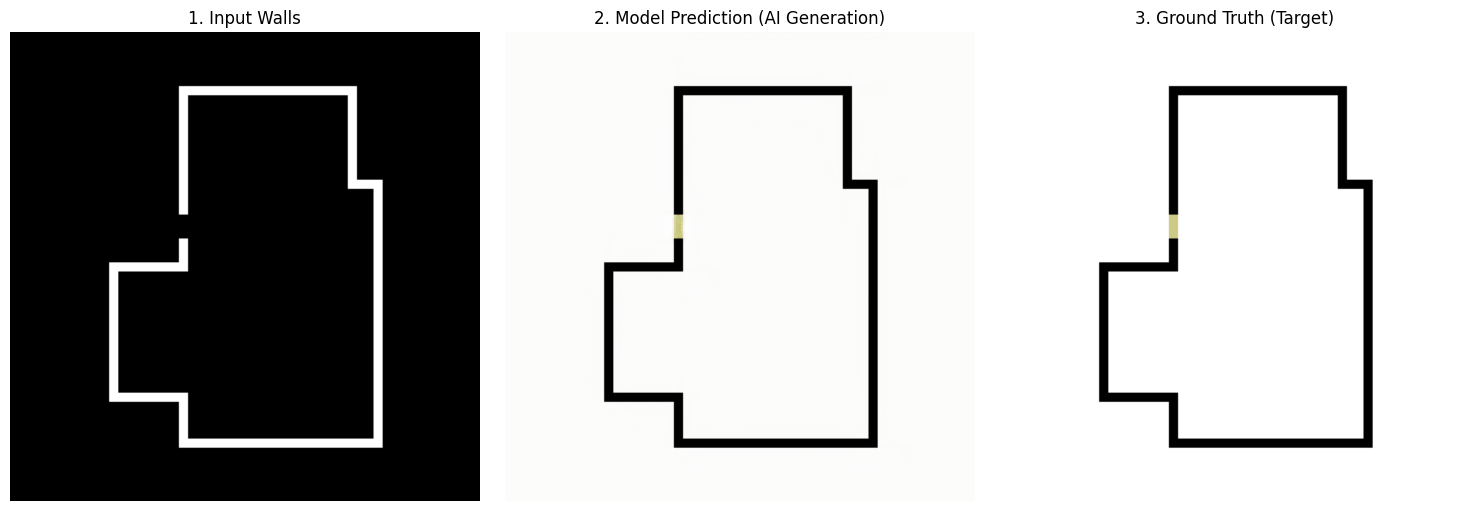

In [12]:
model.eval()
inputs, targets = next(iter(dataloader))

with torch.no_grad():
    outputs = model(inputs.to(device)).cpu()

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("1. Input Walls")
plt.imshow(inputs[0].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. Model Prediction (AI Generation)")
plt.imshow(outputs[0].permute(1, 2, 0))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("3. Ground Truth (Target)")
plt.imshow(targets[0].permute(1, 2, 0))
plt.axis('off')

plt.tight_layout()
plt.show()